## Machine Learning Assignment (Classification)

# Adult Census Income Dataset

# Part 1 — Data Understanding

Import libraries

In [21]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

Load Dataset

In [22]:
# Since this dataset has no header, we need to provide the column names manually.

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

Load dataset

In [23]:
df = pd.read_csv(
    r"C:\Users\saba\Downloads\census+income\adult.data",
    header=None,
    names=column_names,
    skipinitialspace=True
)

In [24]:
# Display First Five Records
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [25]:
# Display Last Five Records
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


Understand the dataset

In [26]:
# Display Shape
df.shape

(32561, 15)

In [27]:
# Display Column Names
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [28]:
# Display Data Types
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [29]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [30]:
# Statistical Summary (Numerical)
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [31]:
# Statistical Summary (Categorical)
df.describe(include='object')

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [32]:
# Number of Rows
print("Number of Rows:", df.shape[0])

Number of Rows: 32561


In [33]:
# Number of Columns
print("Number of Columns:", df.shape[1])

Number of Columns: 15


In [34]:
# Number of Numerical Features
numerical_features = df.select_dtypes(include=['int64','float64']).columns

print(numerical_features)

print("Total Numerical Features:", len(numerical_features))


Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Total Numerical Features: 6


In [35]:
# Number of Categorical Features
categorical_features = df.select_dtypes(include='object').columns

print(categorical_features)

print("Total Categorical Features:", len(categorical_features))


Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')
Total Categorical Features: 9


In [36]:
# Target Variable
target = "income"

print("Target Variable:", target)

Target Variable: income


# Part 2 — Data Cleaning

In [37]:
# Check Missing Values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [38]:
# Display Missing Value Percentages
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
income            0.0
dtype: float64

In [39]:
# Handle Missing Values

"""In this dataset, missing values are represented by "?" instead of NaN.

First convert ? into missing values:"""

df.replace("?", np.nan, inplace=True)

In [40]:
# Check Missing Values Again
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [41]:
# Handle Numerical Missing Values

# Numerical columns:

numerical_features = df.select_dtypes(include=['int64','float64']).columns

numerical_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [42]:
# Fill numerical missing values using median:

for col in numerical_features:
    df[col].fillna(df[col].median(), inplace=True)

In [43]:
# Handle Categorical Missing Values

# Categorical columns:

categorical_features = df.select_dtypes(include='object').columns

categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [44]:
# Fill categorical missing values using mode:

for col in categorical_features:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [45]:
# Verify Missing Values After Handling
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [46]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(24)

In [47]:
# Remove Duplicate Rows
df = df.drop_duplicates()

In [48]:
# Verify Duplicate Removal
df.duplicated().sum()

np.int64(0)

In [49]:
# Check Incorrect Data Types
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

In [50]:
# Convert Incorrect Data Types (If Required)

# Check columns:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education_num   32537 non-null  int64 
 5   marital_status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital_gain    32537 non-null  int64 
 11  capital_loss    32537 non-null  int64 
 12  hours_per_week  32537 non-null  int64 
 13  native_country  32537 non-null  object
 14  income          32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


In [51]:
# No conversion is required but if needed
 
# df['age'] = df['age'].astype(int)

# df['fnlwgt'] = df['fnlwgt'].astype(int)

# df['education_num'] = df['education_num'].astype(int)

# df['capital_gain'] = df['capital_gain'].astype(int)

# df['capital_loss'] = df['capital_loss'].astype(int)

# df['hours_per_week'] = df['hours_per_week'].astype(int)

In [52]:
# Display Unique Values of Every Categorical Column
categorical_features = df.select_dtypes(include='object').columns

for col in categorical_features:
    print("\nUnique values in", col)
    print(df[col].unique())


Unique values in workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

Unique values in education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

Unique values in marital_status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

Unique values in occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']

Unique values in relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

Unique values in race
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

Unique values in sex
['Male' 'Female']

Uniq

In [53]:
# Count Unique Values of Every Categorical Column
for col in categorical_features:
    print(col, ":", df[col].nunique())

workclass : 8
education : 16
marital_status : 7
occupation : 14
relationship : 6
race : 5
sex : 2
native_country : 41
income : 2


In [54]:
# Display Frequency of Every Category
for col in categorical_features:
    print("\nValue Counts of", col)
    print(df[col].value_counts())


Value Counts of workclass
workclass
Private             24509
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Value Counts of education
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

Value Counts of marital_status
marital_status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

Value Counts of occupat

In [55]:
# Check Target Variable Distribution
df['income'].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

# Part 3 — Exploratory Data Analysis (EDA)

In [56]:
# Identify Numerical and Categorical Features
numerical_features = df.select_dtypes(include=['int64','float64']).columns

categorical_features = df.select_dtypes(include='object').columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

Categorical Features:
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


Univariate Analysis of numerical features 

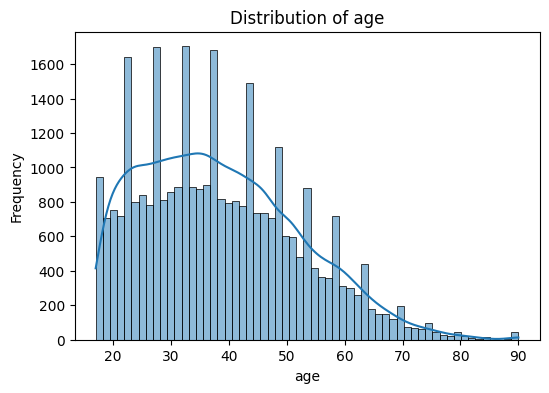

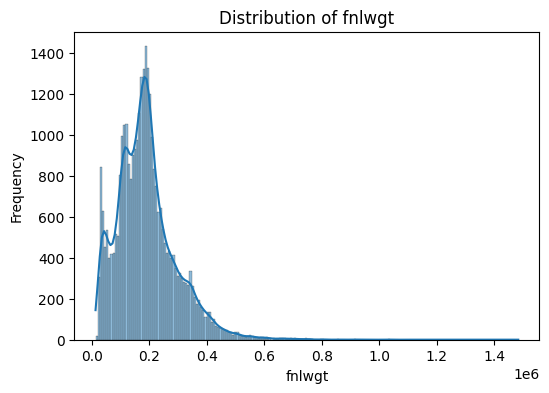

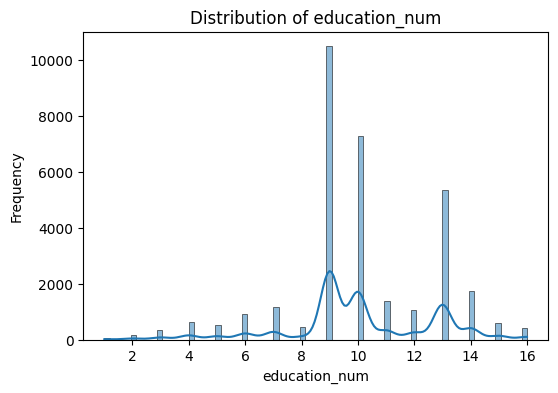

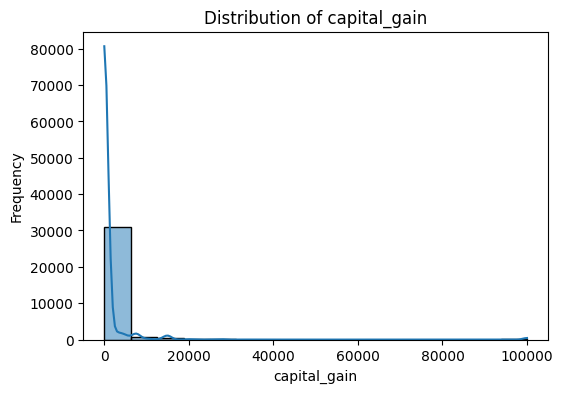

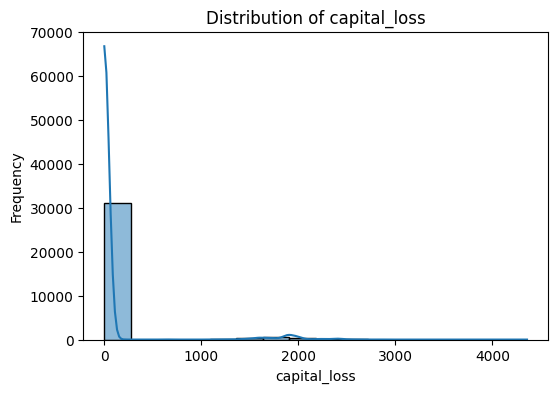

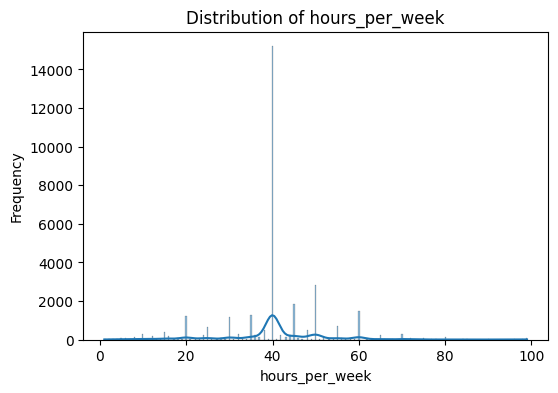

In [57]:
# Histogram + KDE Plot for Every Numerical Feature
for col in numerical_features:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

# Interpretation
Numerical variables show different distributions based on demographic and financial characteristics.
Features like capital_gain and capital_loss are highly right-skewed because most individuals have zero values.
age and hours_per_week show more balanced distributions.

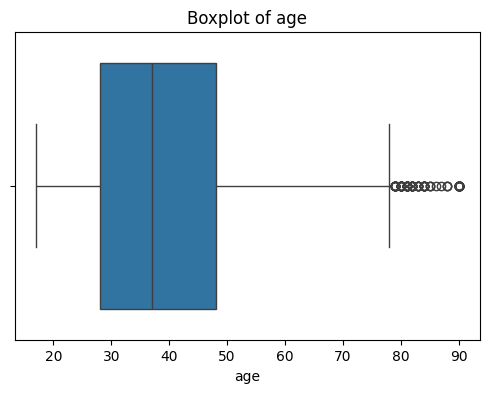

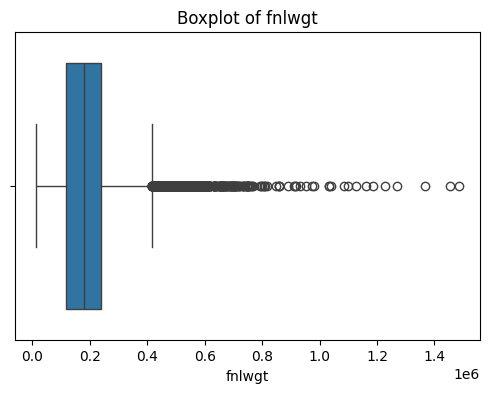

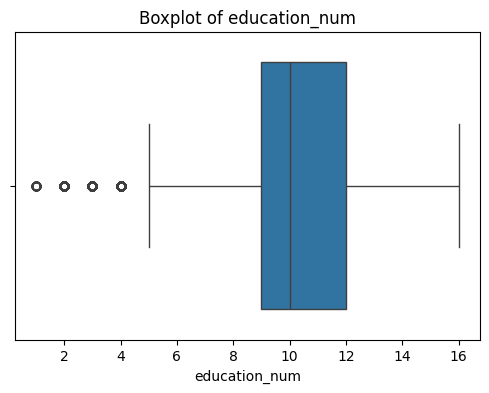

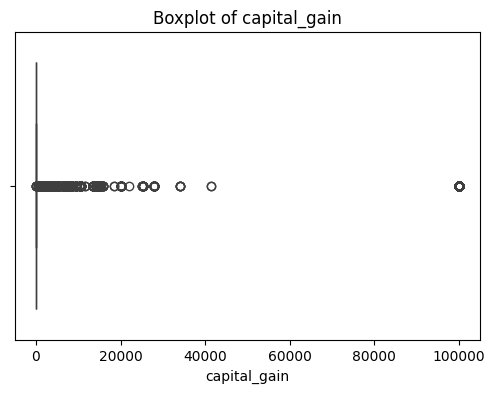

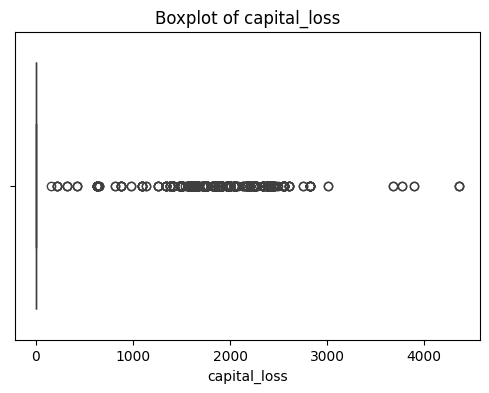

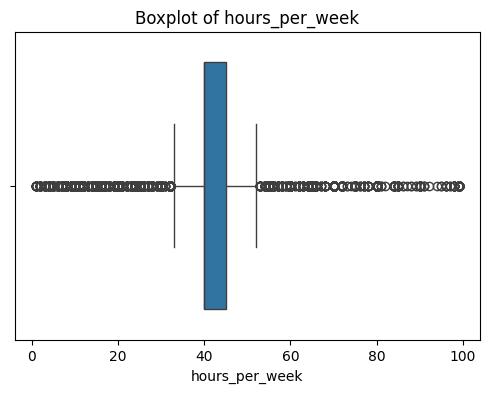

In [58]:
# Boxplot for Every Numerical Feature
for col in numerical_features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.show()

# Interpretation 
Boxplots help identify potential outliers.

Categorical Features

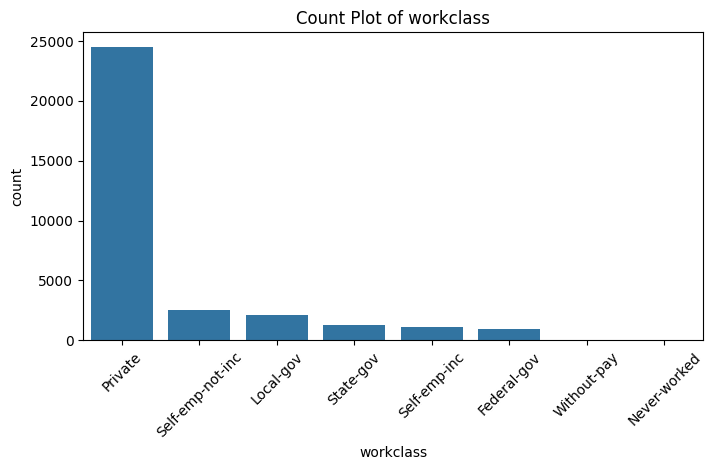

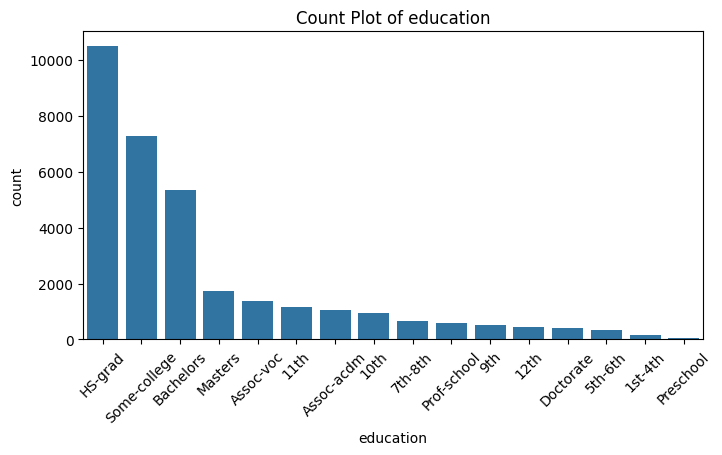

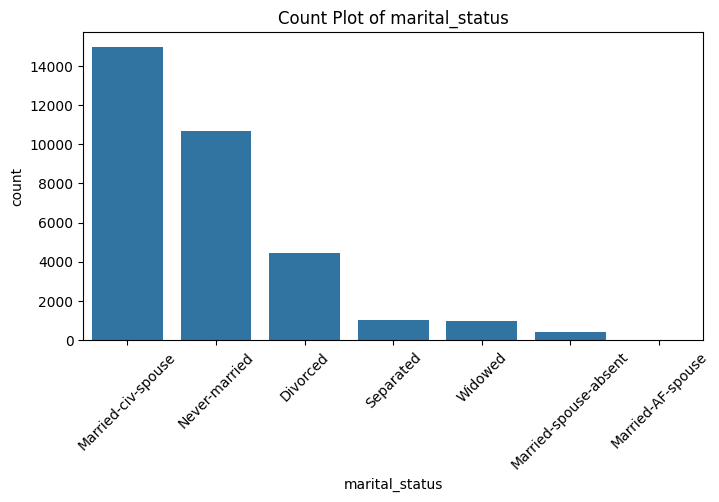

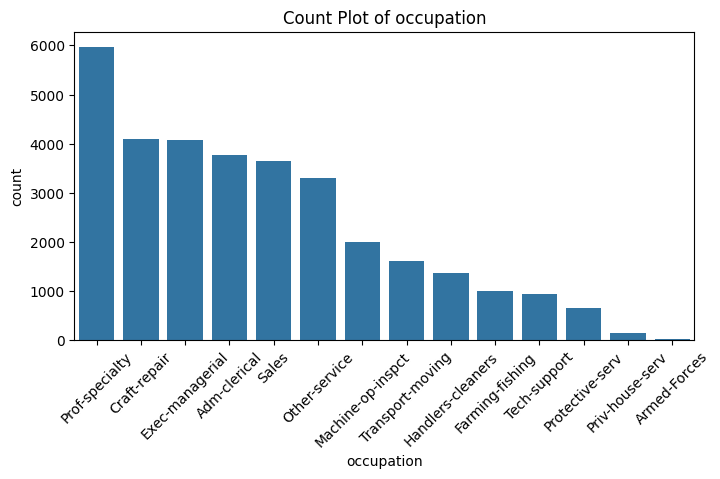

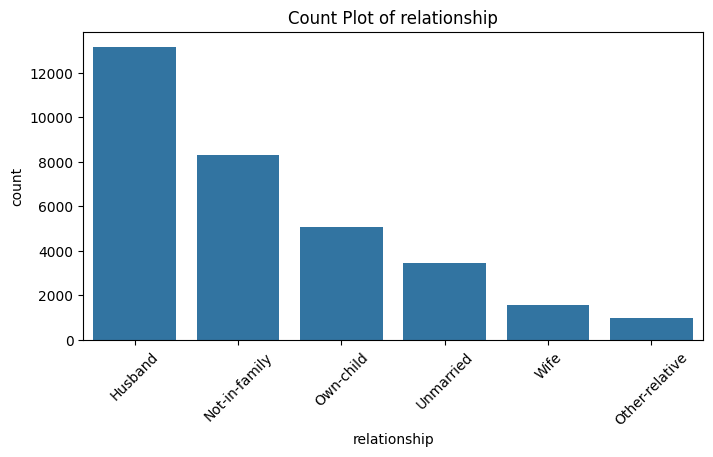

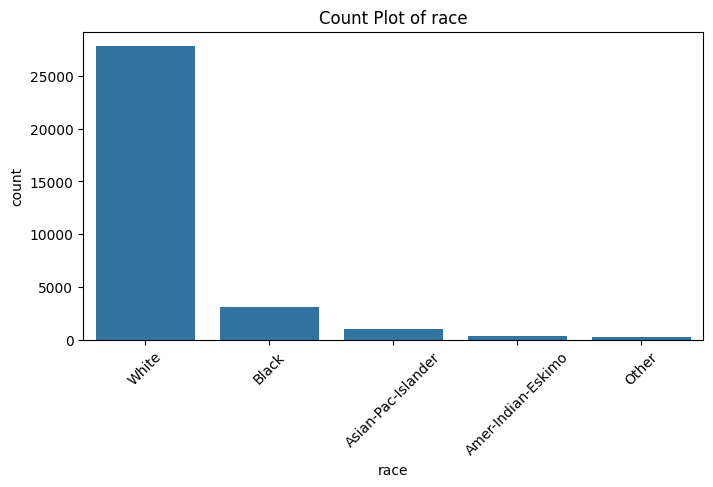

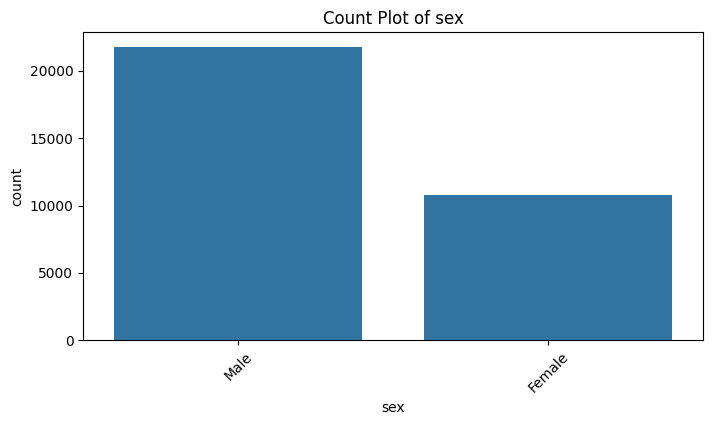

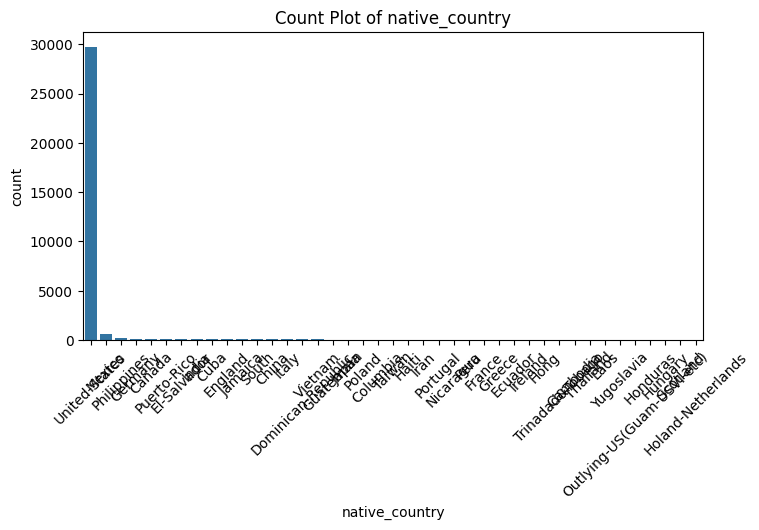

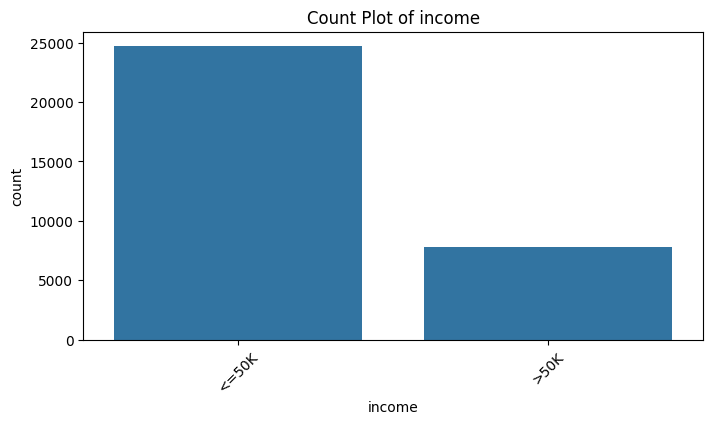

In [59]:
# Count Plot for Every Categorical Feature
for col in categorical_features:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    
    plt.show()

In [60]:
# Value Counts of Every Categorical Feature
for col in categorical_features:
    
    print("\nValue Counts of", col)
    print(df[col].value_counts())


Value Counts of workclass
workclass
Private             24509
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Value Counts of education
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

Value Counts of marital_status
marital_status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

Value Counts of occupat

# Interpretation
Most individuals belong to the <=50K income category.
Some occupations and work classes are more frequent than others.
Categories such as education level and marital status show different distributions among individuals.
Count plots help understand class imbalance and category frequency.

Bivariate Analysis (Classification)

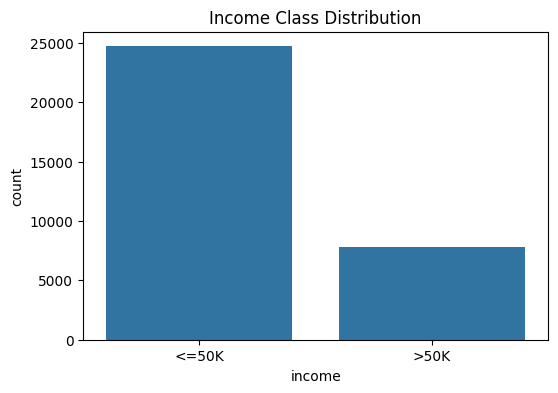

In [61]:
# Target Variable Count Plot
plt.figure(figsize=(6,4))

sns.countplot(
    x='income',
    data=df
)

plt.title("Income Class Distribution")

plt.show()

Numerical Feature vs Target

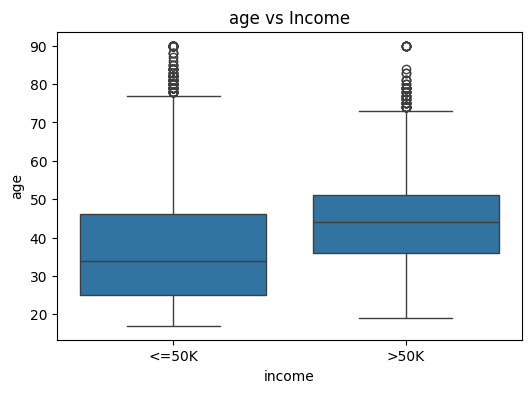

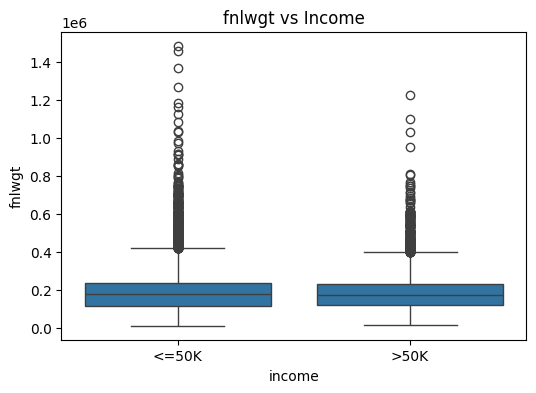

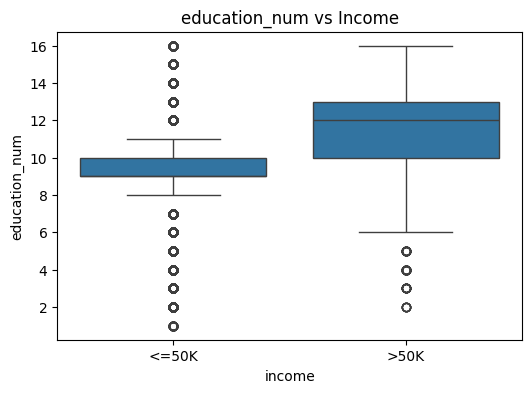

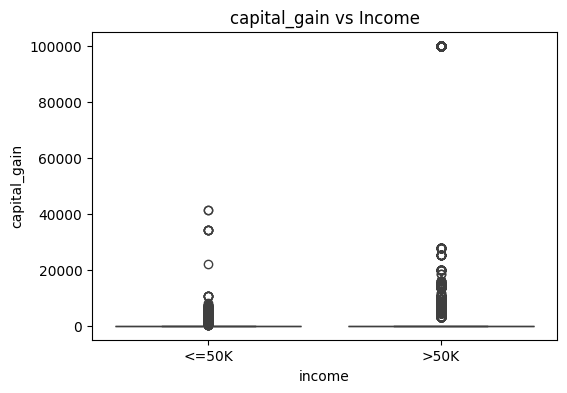

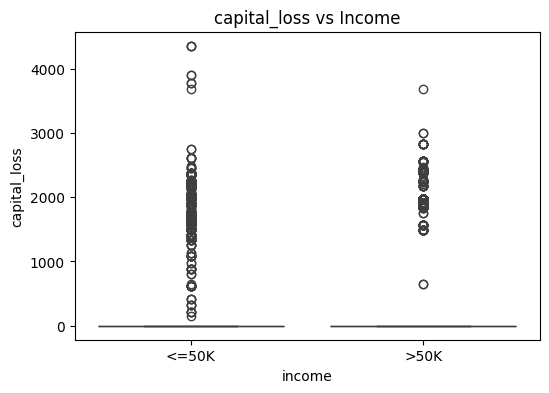

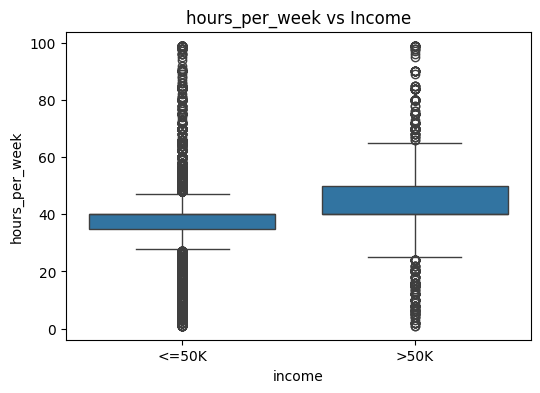

In [62]:

for col in numerical_features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x='income',
        y=col,
        data=df
    )
    
    plt.title(f"{col} vs Income")
    
    plt.show()

Categorical Feature vs Target

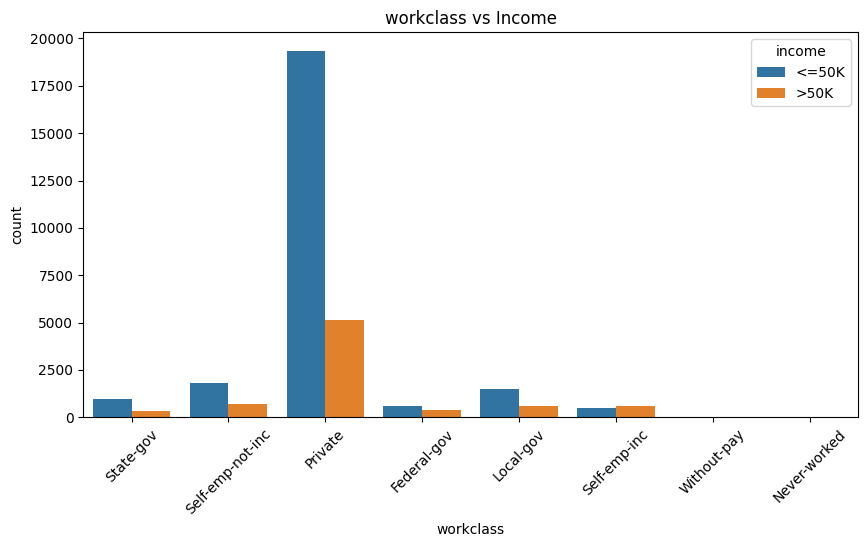

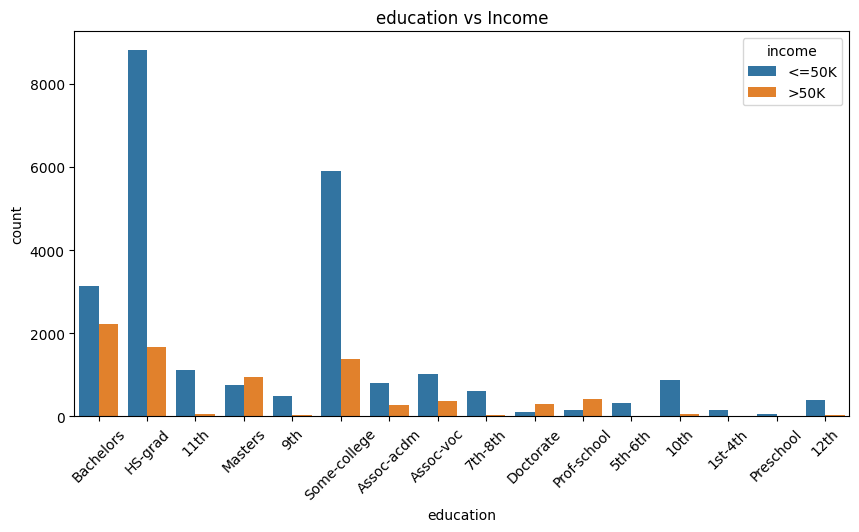

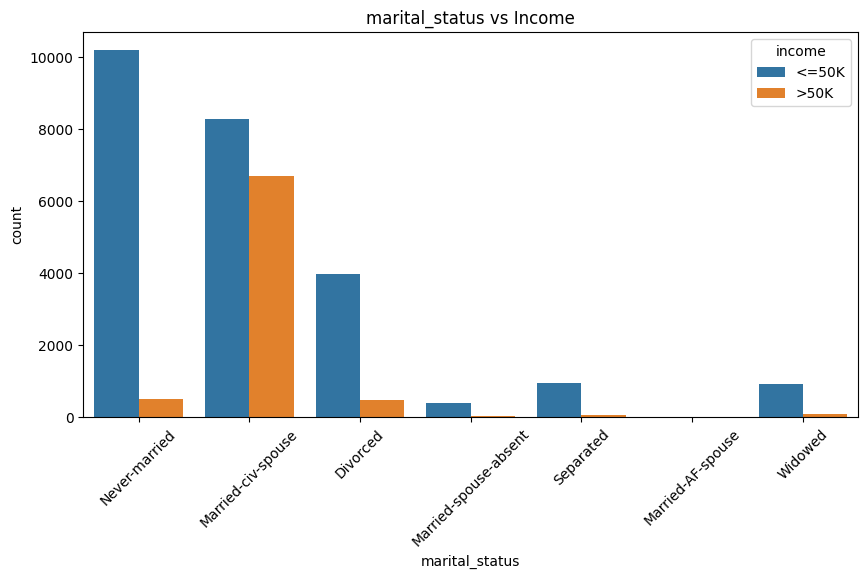

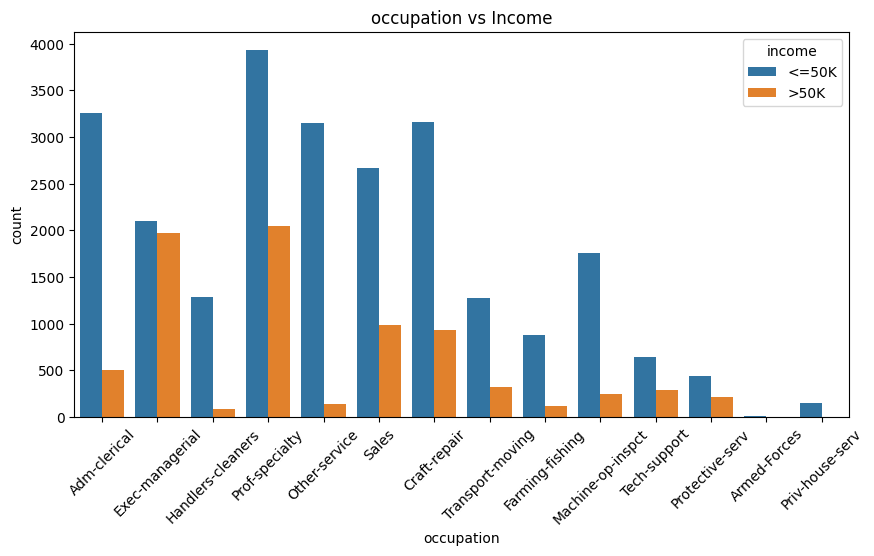

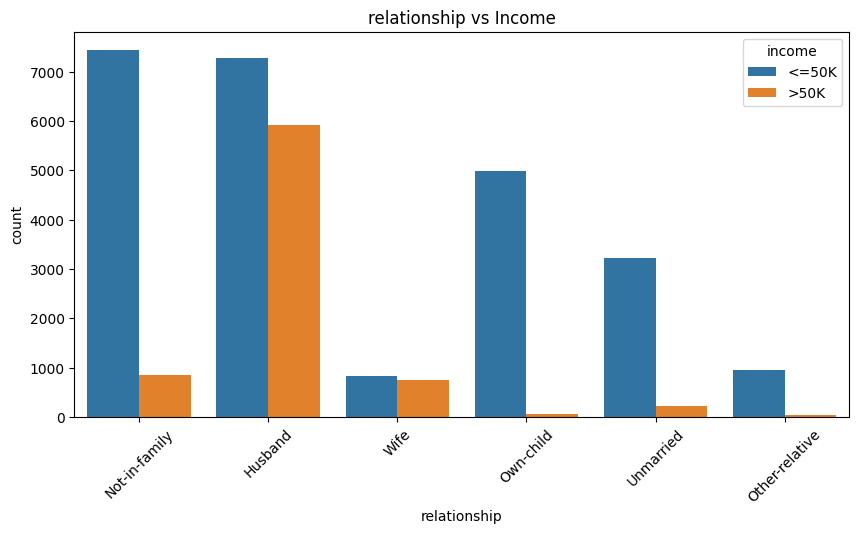

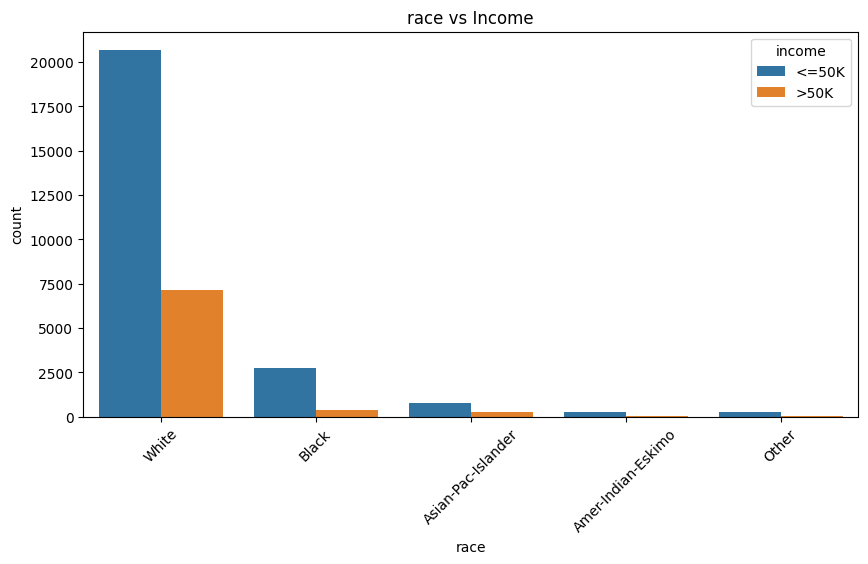

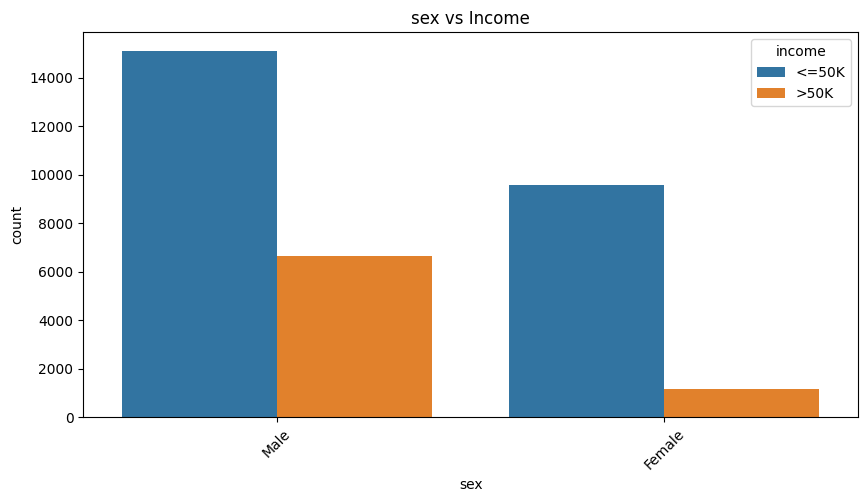

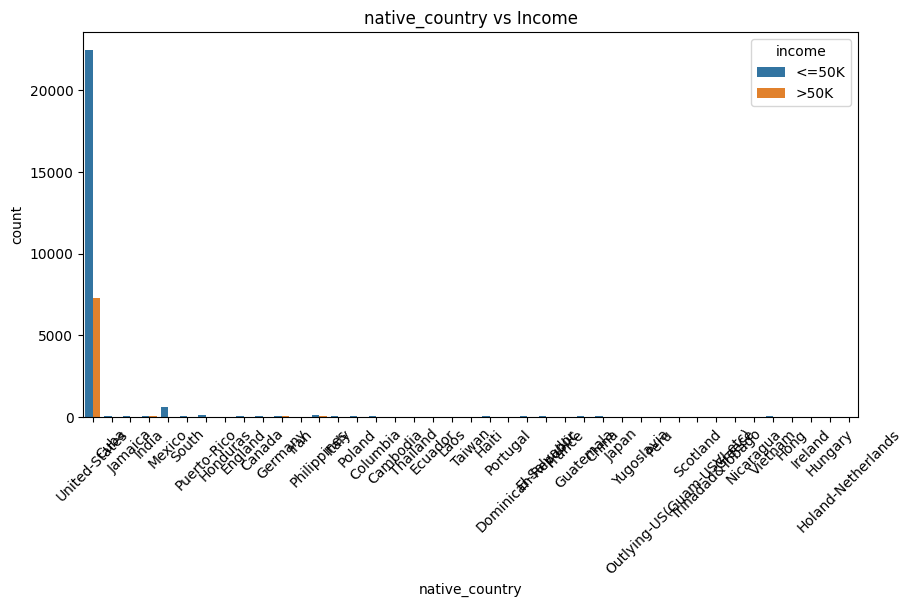

In [63]:
for col in categorical_features[:-1]:
    
    plt.figure(figsize=(10,5))
    
    sns.countplot(
        x=col,
        hue='income',
        data=df
    )
    
    plt.xticks(rotation=45)
    
    plt.title(f"{col} vs Income")
    
    plt.show()

In [64]:
# ([:-1] excludes income itself because income is the target.)

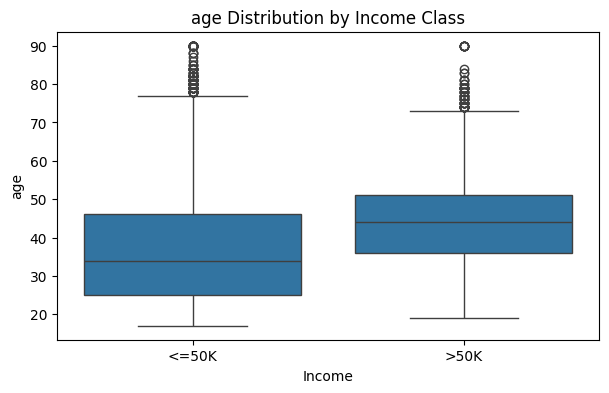

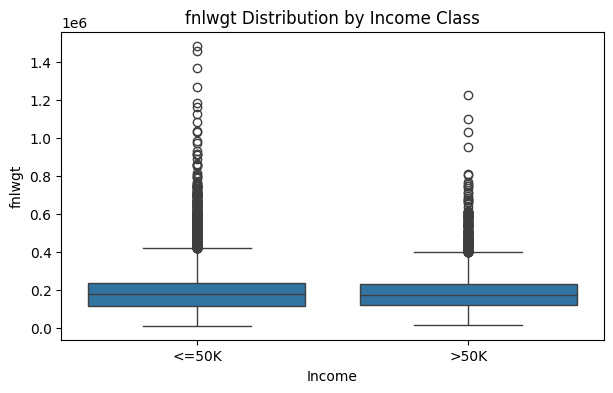

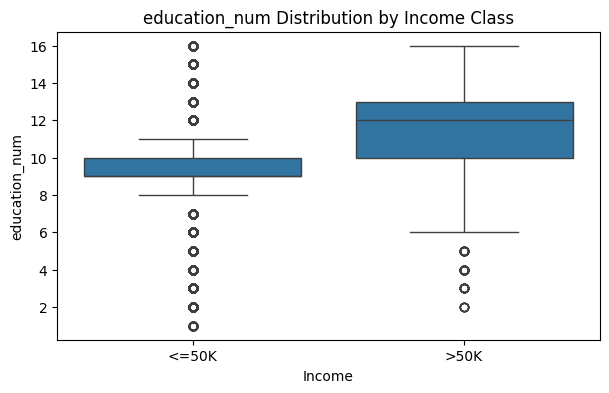

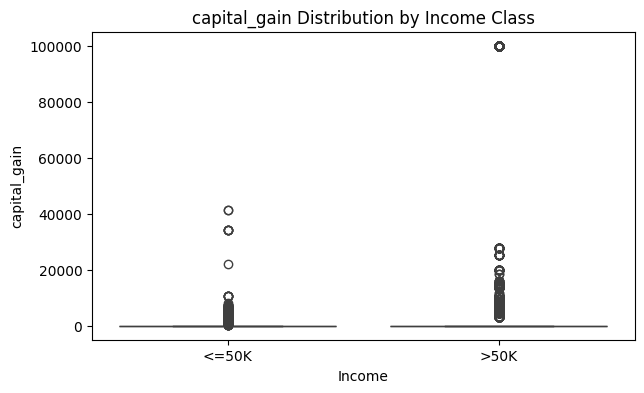

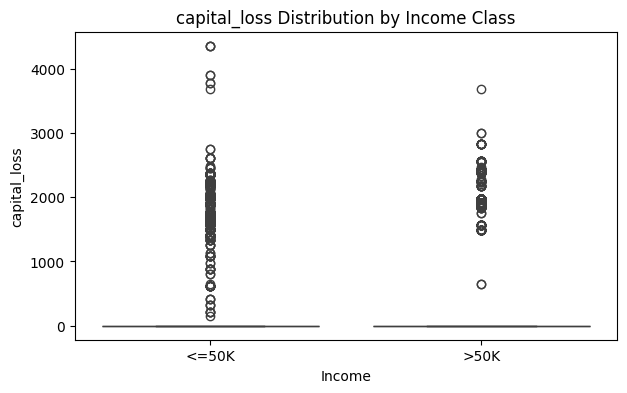

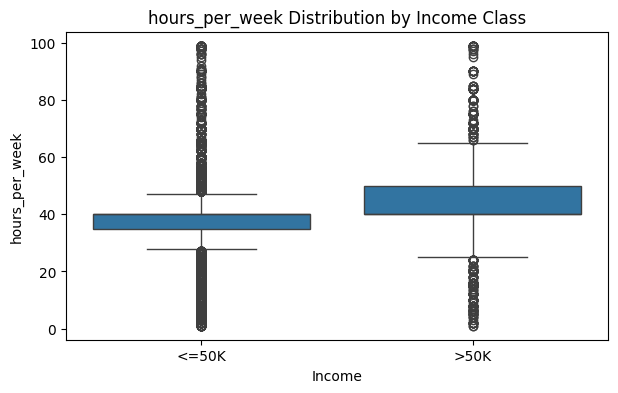

In [65]:
# Boxplot of Every Numerical Feature Grouped by Income
for col in numerical_features:
    
    plt.figure(figsize=(7,4))
    
    sns.boxplot(
        x='income',
        y=col,
        data=df
    )
    
    plt.title(f"{col} Distribution by Income Class")
    
    plt.xlabel("Income")
    plt.ylabel(col)
    
    plt.show()

## Interpretation 

Boxplots grouped by income class were used to compare numerical feature distributions between individuals earning <=50K and >50K. Features such as age, education number, hours per week, and capital gain show differences between the two classes. Higher-income individuals generally show higher education levels, more working hours, and greater capital gains compared with lower-income individuals.

# Part 4 — Outlier Detection

In [66]:
# Import Required Library
from scipy.stats import zscore

In [67]:
# Numerical Features
numerical_features = df.select_dtypes(include=['int64','float64']).columns

numerical_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

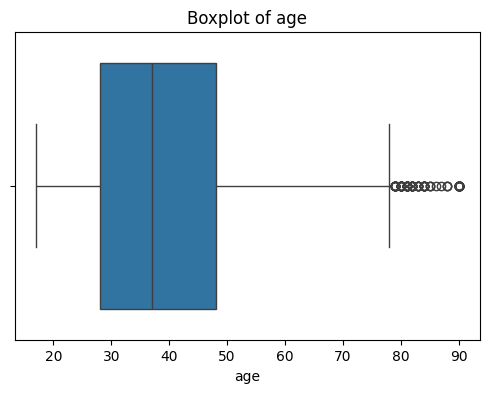

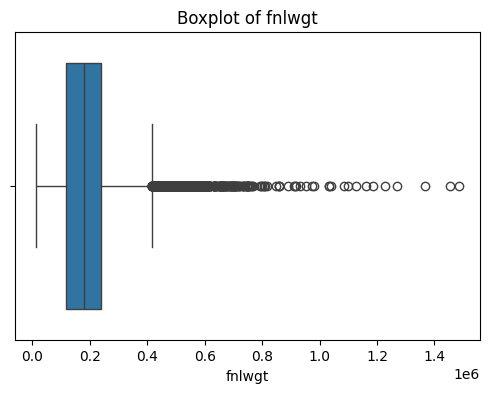

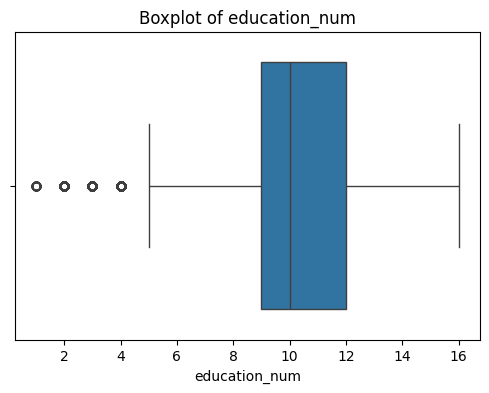

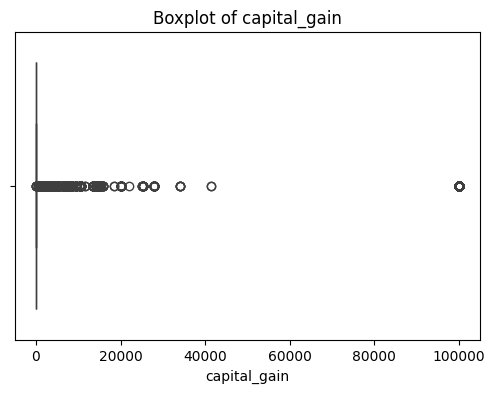

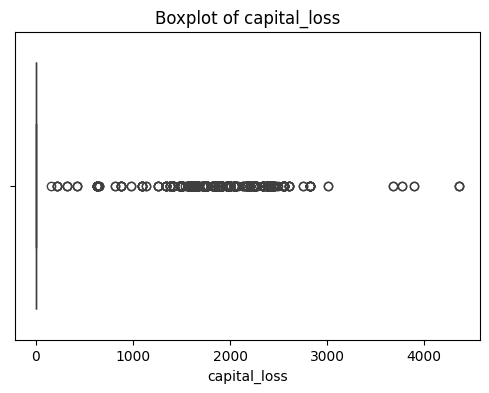

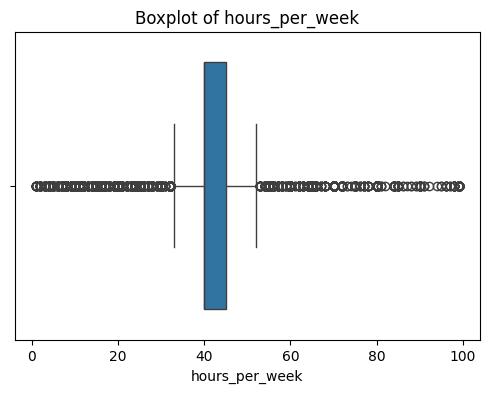

In [68]:
# Method 1 — Boxplot Visualization
for col in numerical_features:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

In [69]:
# Method 2 — IQR Method

def detect_outliers_iqr(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]
    
    print(column)
    print("Number of Outliers:", len(outliers))
    print("--------------------------")
# Apply IQR on All Numerical Features
for col in numerical_features:
    
    detect_outliers_iqr(df, col)

age
Number of Outliers: 142
--------------------------
fnlwgt
Number of Outliers: 993
--------------------------
education_num
Number of Outliers: 1193
--------------------------
capital_gain
Number of Outliers: 2712
--------------------------
capital_loss
Number of Outliers: 1519
--------------------------
hours_per_week
Number of Outliers: 9002
--------------------------


In [70]:
# Method 3 — Z-score Method

def detect_outliers_zscore(data, column):
    
    z_scores = zscore(data[column])
    
    outliers = data[
        np.abs(z_scores) > 3
    ]
    
    print(column)
    print("Number of Outliers:", len(outliers))
    print("--------------------------")
# Apply Z-score on All Numerical Features
for col in numerical_features:
    
    detect_outliers_zscore(df, col)

age
Number of Outliers: 120
--------------------------
fnlwgt
Number of Outliers: 346
--------------------------
education_num
Number of Outliers: 216
--------------------------
capital_gain
Number of Outliers: 215
--------------------------
capital_loss
Number of Outliers: 1470
--------------------------
hours_per_week
Number of Outliers: 440
--------------------------


Should We Remove Outliers?

For this dataset:

No, we will not remove outliers.

Justification

Outliers were detected using Boxplots, IQR method, and Z-score method. However, they were not removed because extreme values in features such as capital gain, capital loss, and hours worked may represent genuine observations rather than errors. Removing these records could reduce important information and negatively affect model performance.

# Part 5 — Feature Engineering

In [71]:
# Separate Features and Target Variable

# Target variable = income

X = df.drop('income', axis=1)

y = df['income']

In [72]:
# Identify Categorical and Numerical Features
numerical_features = X.select_dtypes(include=['int64','float64']).columns

categorical_features = X.select_dtypes(include='object').columns


print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

Categorical Features:
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='object')


In [73]:
# Label Encoding

# Import Label Encoder:

from sklearn.preprocessing import LabelEncoder

In [74]:
# Create encoder:

le = LabelEncoder()

# Apply Label Encoding to Target Variable

y = le.fit_transform(y)

# Check encoded classes:

print(le.classes_)

['<=50K' '>50K']


Why Label Encoding?

The target variable (income) contains two classes (<=50K and >50K). Label Encoding was applied because it is a binary classification problem, and converting the classes into numerical form is required for machine learning algorithms.

In [75]:
# One-Hot Encoding

# For input categorical features:

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

In [78]:
# Check New Dataset
X_encoded.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native_country_Canada,native_country_China,native_country_Columbia,native_country_Cuba,native_country_Dominican-Republic,native_country_Ecuador,native_country_El-Salvador,native_country_England,native_country_France,native_country_Germany,native_country_Greece,native_country_Guatemala,native_country_Haiti,native_country_Holand-Netherlands,native_country_Honduras,native_country_Hong,native_country_Hungary,native_country_India,native_country_Iran,native_country_Ireland,native_country_Italy,native_country_Jamaica,native_country_Japan,native_country_Laos,native_country_Mexico,native_country_Nicaragua,native_country_Outlying-US(Guam-USVI-etc),native_country_Peru,native_country_Philippines,native_country_Poland,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

In [ ]:
# Check Shape After Encoding
X_encoded.shape

(32537, 97)

Why One-Hot Encoding?

One-Hot Encoding was applied to categorical input features because variables such as education, occupation, marital status, and native country do not have a natural numerical order. One-hot encoding converts categories into binary columns without creating false relationships.

Feature Scaling

In [81]:
# StandardScaler

from sklearn.preprocessing import StandardScaler

In [82]:
# Apply scaling:

standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X_encoded)

In [83]:
# Convert back to DataFrame:

X_standard = pd.DataFrame(
    X_standard,
    columns=X_encoded.columns
)

X_standard.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native_country_Canada,native_country_China,native_country_Columbia,native_country_Cuba,native_country_Dominican-Republic,native_country_Ecuador,native_country_El-Salvador,native_country_England,native_country_France,native_country_Germany,native_country_Greece,native_country_Guatemala,native_country_Haiti,native_country_Holand-Netherlands,native_country_Honduras,native_country_Hong,native_country_Hungary,native_country_India,native_country_Iran,native_country_Ireland,native_country_Italy,native_country_Jamaica,native_country_Japan,native_country_Laos,native_country_Mexico,native_country_Nicaragua,native_country_Outlying-US(Guam-USVI-etc),native_country_Peru,native_country_Philippines,native_country_Poland,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,0.030390,-1.063569,1.134777,0.148292,-0.216743,-0.035664,-0.262201,-0.014669,-1.747266,-0.188461,-0.290990,4.905816,-0.020748,-0.193561,-0.116135,-0.07161,-0.101533,-0.142213,-0.126692,-0.184134,-0.210615,2.253503,-0.113386,-0.689978,-0.236393,-0.039231,-0.134246,-0.536972,-0.026597,-0.923128,-0.114079,1.431869,-0.180353,-0.177426,-0.016634,-0.37939,-0.377852,-0.177333,-0.209579,-0.255919,-0.335452,-0.067368,-0.474479,-0.142662,-0.355464,-0.171249,-0.227192,1.709942,-0.176317,-0.429333,-0.344118,-0.225014,-0.181531,-0.325786,-0.091646,0.413045,0.703020,-0.061096,-0.048067,-0.042622,-0.054114,-0.046433,-0.029348,-0.057171,-0.052666,-0.029868,-0.065026,-0.029868,-0.043694,-0.036799,-0.005544,-0.019993,-0.0248,-0.019993,-0.055524,-0.036377,-0.027169,-0.04742,-0.049957,-0.043694,-0.023527,-0.141537,-0.032343,-0.020748,-0.030882,-0.078247,-0.042982,-0.033741,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181
1,0.836973,-1.008668,1.134777,-0.145975,-0.216743,-2.222483,-0.262201,-0.014669,-1.747266,-0.188461,3.436545,-0.203840,-0.020748,-0.193561,-0.116135,-0.07161,-0.101533,-0.142213,-0.126692,-0.184134,-0.210615,2.253503,-0.113386,-0.689978,-0.236393,-0.039231,-0.134246,-0.536972,-0.026597,1.083273,-0.114079,-0.698388,-0.180353,-0.177426,-0.016634,-0.37939,2.646542,-0.177333,-0.209579,-0.255919,-0.335452,-0.067368,-0.474479,-0.142662,-0.355464,-0.171249,-0.227192,-0.584815,-0.176317,-0.429333,-0.344118,-0.225014,-0.181531,-0.325786,-0.091646,0.413045,0.703020,-0.061096,-0.048067,-0.042622,-0.054114,-0.046433,-0.029348,-0.057171,-0.052666,-0.029868,-0.065026,-0.029868,-0.043694,-0.036799,-0.005544,-0.019993,-0.0248,-0.019993,-0.055524,-0.036377,-0.027169,-0.04742,-0.049957,-0.043694,-0.023527,-0.141537,-0.032343,-0.020748,-0.030882,-0.078247,-0.042982,-0.033741,-0.05929

In [84]:
# MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

In [85]:
# Apply scaling:

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X_encoded)

In [86]:
# Convert to DataFrame:

X_minmax = pd.DataFrame(
    X_minmax,
    columns=X_encoded.columns
)

X_minmax.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native_country_Canada,native_country_China,native_country_Columbia,native_country_Cuba,native_country_Dominican-Republic,native_country_Ecuador,native_country_El-Salvador,native_country_England,native_country_France,native_country_Germany,native_country_Greece,native_country_Guatemala,native_country_Haiti,native_country_Holand-Netherlands,native_country_Honduras,native_country_Hong,native_country_Hungary,native_country_India,native_country_Iran,native_country_Ireland,native_country_Italy,native_country_Jamaica,native_country_Japan,native_country_Laos,native_country_Mexico,native_country_Nicaragua,native_country_Outlying-US(Guam-USVI-etc),native_country_Peru,native_country_Philippines,native_country_Poland,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

Why Feature Scaling is Required?

Feature scaling is required because machine learning algorithms calculate distances or optimize weights based on feature values. Features with larger ranges can dominate smaller features. Scaling ensures that all features contribute equally during model training.

Models Requiring Scaling
Logistic Regression
Support Vector Machine (SVM) 
K-Nearest Neighbors (KNN) 
Neural Networks 

Models Not Requiring Scaling
Decision Tree
Random Forest 
Other tree-based models 

In [87]:
# Feature Selection Using Correlation

# Create correlation matrix:

correlation = X_encoded.corr()

In [88]:
# Correlation with Target

# Add target temporarily:

correlation_target = X_encoded.copy()

correlation_target['income'] = y

correlation_target.corr()['income'].sort_values(
    ascending=False
)

income                               1.000000
marital_status_Married-civ-spouse    0.444609
education_num                        0.335272
age                                  0.234037
hours_per_week                       0.229658
                                       ...   
relationship_Unmarried              -0.142948
occupation_Other-service            -0.156332
relationship_Not-in-family          -0.188299
relationship_Own-child              -0.228593
marital_status_Never-married        -0.318285
Name: income, Length: 98, dtype: float64

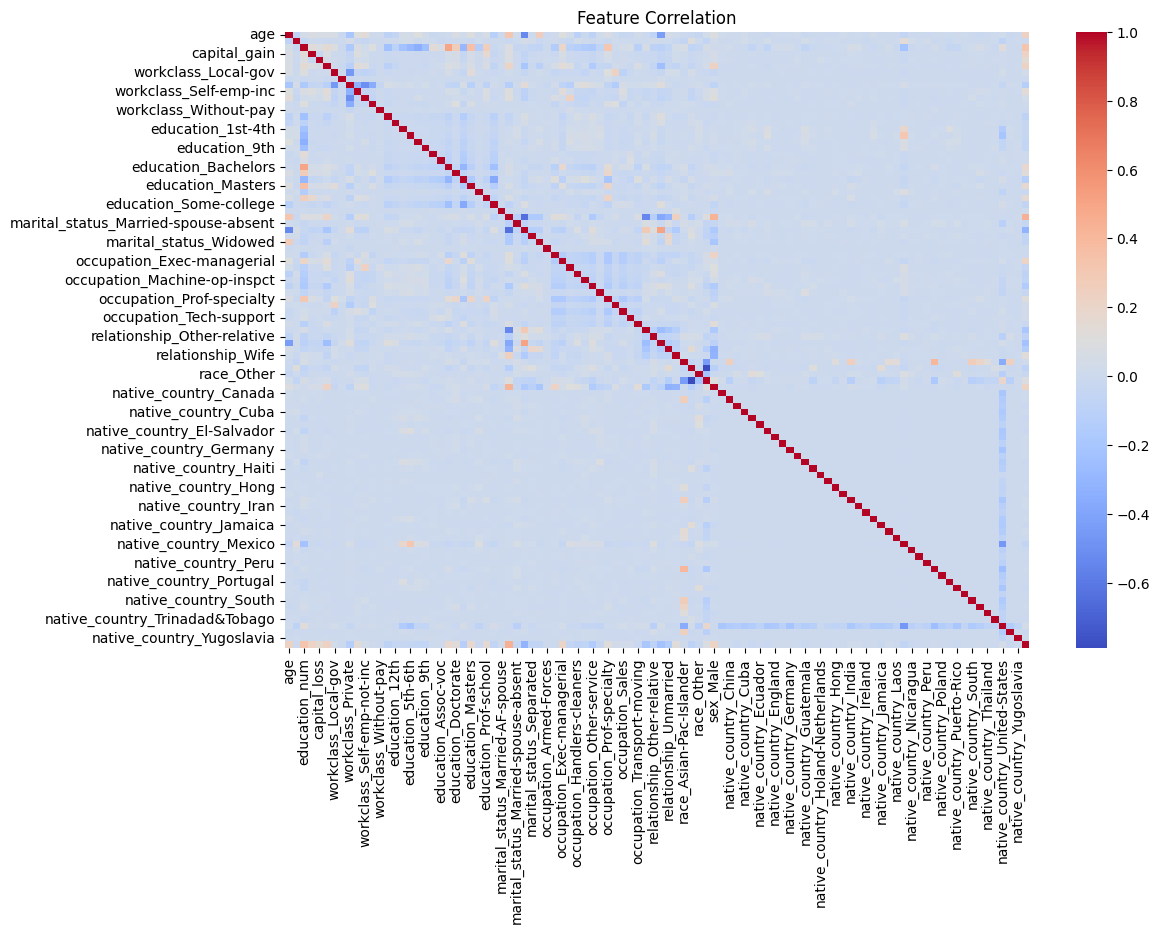

In [89]:
# Correlation Heatmap (For Feature Selection Only)
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_target.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation")

plt.show()

Interpretation

Correlation analysis helps identify features that have stronger relationships with the target variable. Features related to education level, capital gain, hours worked, and age generally show stronger relationships with income.

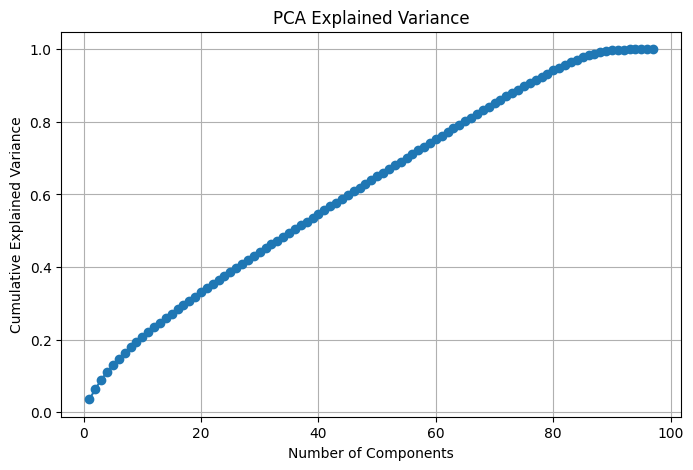

Original Features: (32537, 97)
After PCA: (32537, 82)


In [90]:
# Feature Selection Using PCA

# Import PCA:

from sklearn.decomposition import PCA

#Apply PCA
pca = PCA()
pca.fit(X_standard)

# Explained Variance
explained_variance = pca.explained_variance_ratio_
explained_variance

# Cumulative Explained Variance
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

# Plot PCA Variance
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

# Select Components Explaining 95% Variance
pca_95 = PCA(n_components=0.95)

X_pca = pca_95.fit_transform(X_standard)

# Compare Shapes
print("Original Features:", X_standard.shape)

print("After PCA:", X_pca.shape)

Compare Feature Selection Methods

Correlation-based selection identifies important original features based on their relationship with the target variable. PCA reduces dimensionality by transforming original features into new principal components while preserving most of the information. Correlation keeps interpretable features, while PCA improves computational efficiency by reducing feature dimensions.

# Part 6 — Train-Test Split

In [91]:
# Import Train-Test Split
from sklearn.model_selection import train_test_split

In [92]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_standard,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [93]:
# Check Training and Testing Shape
print("X_train Shape:", X_train.shape)

print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)

print("y_test Shape:", y_test.shape)

X_train Shape: (26029, 97)
X_test Shape: (6508, 97)
y_train Shape: (26029,)
y_test Shape: (6508,)


# Part 7 — Model Training (Classification)

Model 1 — Logistic Regression

In [ ]:
# Import model
from sklearn.linear_model import LogisticRegression

In [95]:
# Create Model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [96]:
# Train Model
logistic_model.fit(
    X_train,
    y_train
)
# Predictions
y_pred_logistic = logistic_model.predict(X_test)

Model 2 — Decision Tree Classifier

In [97]:
# Import Model
from sklearn.tree import DecisionTreeClassifier
# Create Model
decision_tree = DecisionTreeClassifier(
    random_state=42
)
# Train Model
decision_tree.fit(
    X_train,
    y_train
)
# Predictions
y_pred_tree = decision_tree.predict(X_test)

Model 3 — Naive Bayes

In [98]:
# Import Model
from sklearn.naive_bayes import GaussianNB
# Create Model
naive_bayes = GaussianNB()
# Train Model
naive_bayes.fit(
    X_train,
    y_train
)
# Predictions
y_pred_nb = naive_bayes.predict(X_test)

Model 4 — Support Vector Machine (SVM)

In [101]:
# Import Model
from sklearn.svm import SVC

# Create Model
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    cache_size=2000,
    random_state=42
)

# Train Model
svm_model.fit(
    X_train,
    y_train
)

# Predictions
y_pred_svm = svm_model.predict(X_test)

Model 5 — K-Nearest Neighbors (KNN)

In [102]:
# Import Model
from sklearn.neighbors import KNeighborsClassifier
# Create Model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)
# Train Model
knn_model.fit(
    X_train,
    y_train
)
# Predictions
y_pred_knn = knn_model.predict(X_test)

In [103]:
# Verify Predictions
print("Logistic Regression:", y_pred_logistic[:5])

print("Decision Tree:", y_pred_tree[:5])

print("Naive Bayes:", y_pred_nb[:5])

print("SVM:", y_pred_svm[:5])

print("KNN:", y_pred_knn[:5])

Logistic Regression: [0 1 0 0 0]
Decision Tree: [0 0 0 0 0]
Naive Bayes: [1 1 0 1 1]
SVM: [0 1 0 0 0]
KNN: [0 1 0 1 0]


# Part 8 — Model Evaluation (Classification)

In [104]:
# Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Logistic Regression
Accuracy: 0.8566379840196681
Precision: 0.7425515660809778
Recall: 0.6198979591836735
F1 Score: 0.67570385818561


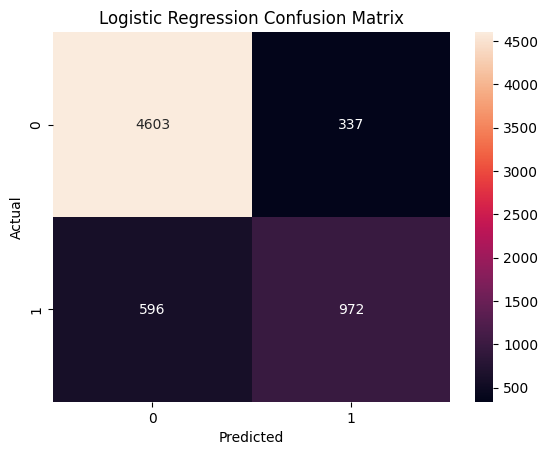

In [111]:
# Logistic Regression Evaluation

print("Logistic Regression")

print("Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("Precision:",
      precision_score(y_test, y_pred_logistic))

print("Recall:",
      recall_score(y_test, y_pred_logistic))

print("F1 Score:",
      f1_score(y_test, y_pred_logistic))
# Confusion Matrix
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Decision Tree
Accuracy: 0.8182237246465888
Precision: 0.6222222222222222
Recall: 0.625
F1 Score: 0.623608017817372


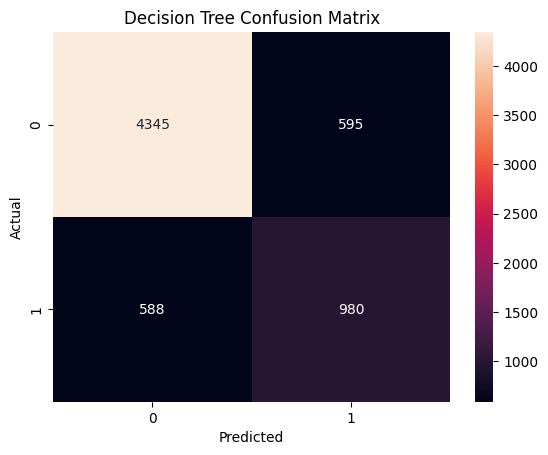

In [107]:
# Decision Tree Evaluation
print("Decision Tree")

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("Precision:",
      precision_score(y_test, y_pred_tree))

print("Recall:",
      recall_score(y_test, y_pred_tree))

print("F1 Score:",
      f1_score(y_test, y_pred_tree))
# Confusion Matrix
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


Naive Bayes
Accuracy: 0.4154886293792256
Precision: 0.2884979190314037
Recall: 0.9725765306122449
F1 Score: 0.4449956229938722


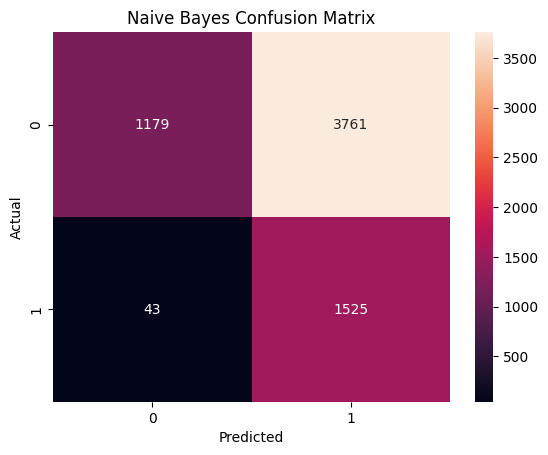

In [108]:
# Naive Bayes Evaluation
print("Naive Bayes")

print("Accuracy:",
      accuracy_score(y_test, y_pred_nb))

print("Precision:",
      precision_score(y_test, y_pred_nb))

print("Recall:",
      recall_score(y_test, y_pred_nb))

print("F1 Score:",
      f1_score(y_test, y_pred_nb))
# Confusion Matrix
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d'
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Support Vector Machine
Accuracy: 0.8529502151198525
Precision: 0.7573715248525695
Recall: 0.5733418367346939
F1 Score: 0.6526315789473685


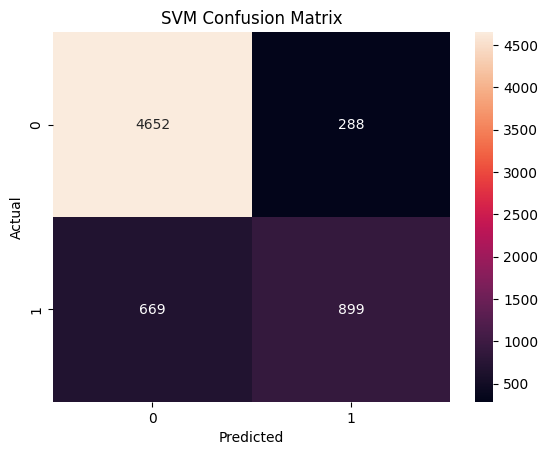

In [109]:
# SVM Evaluation
print("Support Vector Machine")

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))
# Confusion Matrix
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

K-Nearest Neighbors
Accuracy: 0.8294406883835279
Precision: 0.6642754662840746
Recall: 0.5905612244897959
F1 Score: 0.62525320729237


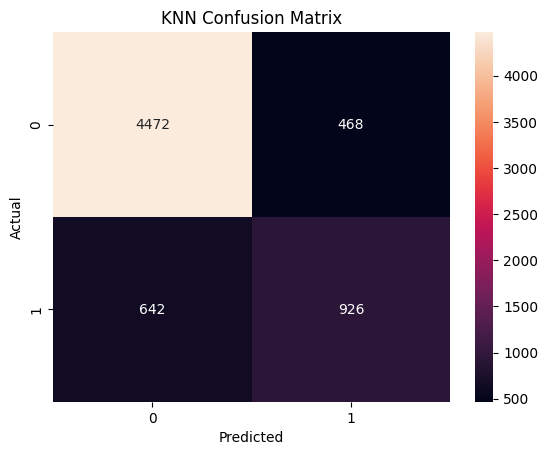

In [110]:
# KNN Evaluation
print("K-Nearest Neighbors")

print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print("Precision:",
      precision_score(y_test, y_pred_knn))

print("Recall:",
      recall_score(y_test, y_pred_knn))

print("F1 Score:",
      f1_score(y_test, y_pred_knn))
# Confusion Matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d'
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [112]:
# Create Model Comparison Table
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes",
        "SVM",
        "KNN"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_logistic),
        accuracy_score(y_test,y_pred_tree),
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_svm),
        accuracy_score(y_test,y_pred_knn)
    ],

    "Precision":[
        precision_score(y_test,y_pred_logistic),
        precision_score(y_test,y_pred_tree),
        precision_score(y_test,y_pred_nb),
        precision_score(y_test,y_pred_svm),
        precision_score(y_test,y_pred_knn)
    ],

    "Recall":[
        recall_score(y_test,y_pred_logistic),
        recall_score(y_test,y_pred_tree),
        recall_score(y_test,y_pred_nb),
        recall_score(y_test,y_pred_svm),
        recall_score(y_test,y_pred_knn)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_logistic),
        f1_score(y_test,y_pred_tree),
        f1_score(y_test,y_pred_nb),
        f1_score(y_test,y_pred_svm),
        f1_score(y_test,y_pred_knn)
    ]
})


comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.856638,0.742552,0.619898,0.675704
1,Decision Tree,0.818224,0.622222,0.625000,0.623608
2,Naive Bayes,0.415489,0.288498,0.972577,0.444996
3,SVM,0.852950,0.757372,0.573342,0.652632
4,KNN,0.829441,0.664275,0.590561,0.625253


In [113]:
# Find Best Model
best_model = comparison.loc[
    comparison['F1 Score'].idxmax()
]


Interpretation 

All classification models were evaluated using accuracy, precision, recall, and F1-score. The comparison table shows the performance differences among models. The best model was selected based on the highest F1-score because the dataset is imbalanced, with more individuals belonging to the <=50K income class.

# Part 9 — Prediction (Classification)

In [114]:
# 1. Logistic Regression — 5 Predictions
logistic_prediction_table = pd.DataFrame({

    "Actual": y_test[:5],

    "Predicted": y_pred_logistic[:5]

})

logistic_prediction_table

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0


In [115]:
# 2. Decision Tree — 5 Predictions
tree_prediction_table = pd.DataFrame({

    "Actual": y_test[:5],

    "Predicted": y_pred_tree[:5]

})

tree_prediction_table

,Actual,Predicted
0,0,0
1,1,0
2,0,0
3,0,0
4,0,0


In [116]:
# 3. Naive Bayes — 5 Predictions
nb_prediction_table = pd.DataFrame({

    "Actual": y_test[:5],

    "Predicted": y_pred_nb[:5]

})

nb_prediction_table

,Actual,Predicted
0,0,1
1,1,1
2,0,0
3,0,1
4,0,1


In [117]:
# 4. SVM — 5 Predictions
svm_prediction_table = pd.DataFrame({

    "Actual": y_test[:5],

    "Predicted": y_pred_svm[:5]

})

svm_prediction_table

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0


In [118]:
# 5. KNN — 5 Predictions
knn_prediction_table = pd.DataFrame({

    "Actual": y_test[:5],

    "Predicted": y_pred_knn[:5]

})

knn_prediction_table

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,0,1
4,0,0
